Suiting the quantum representation to permutation representation

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
m = 20
j = 20
cur_range = 3
total = 2*j

In [4]:
cur_angle = np.random.uniform()*2

In [5]:
cur_angle

1.2324532704647488

In [ ]:
if cur_angle < 1:
    cur_middle = 
elif cur_angle >= 1:

In [38]:
test_sample = np.random.normal(0, 0.08)
test_sample

0.008865027470348891

(array([1.000e+00, 1.000e+00, 0.000e+00, 4.000e+00, 1.000e+00, 4.000e+00,
        4.000e+00, 2.000e+00, 6.000e+00, 1.200e+01, 1.000e+01, 1.600e+01,
        2.200e+01, 3.800e+01, 3.000e+01, 5.100e+01, 7.000e+01, 9.600e+01,
        9.800e+01, 1.250e+02, 1.710e+02, 1.930e+02, 2.270e+02, 2.560e+02,
        3.640e+02, 4.110e+02, 4.660e+02, 5.750e+02, 6.990e+02, 7.970e+02,
        9.680e+02, 9.890e+02, 1.206e+03, 1.343e+03, 1.572e+03, 1.679e+03,
        1.828e+03, 2.064e+03, 2.200e+03, 2.374e+03, 2.592e+03, 2.697e+03,
        2.883e+03, 2.962e+03, 3.179e+03, 3.242e+03, 3.257e+03, 3.474e+03,
        3.392e+03, 3.454e+03, 3.378e+03, 3.301e+03, 3.236e+03, 3.288e+03,
        3.163e+03, 3.006e+03, 2.936e+03, 2.606e+03, 2.455e+03, 2.377e+03,
        2.145e+03, 2.019e+03, 1.845e+03, 1.663e+03, 1.483e+03, 1.331e+03,
        1.267e+03, 9.890e+02, 8.720e+02, 7.790e+02, 7.010e+02, 5.420e+02,
        4.370e+02, 3.890e+02, 3.610e+02, 2.540e+02, 2.250e+02, 1.820e+02,
        1.550e+02, 1.280e+02, 8.200e+0

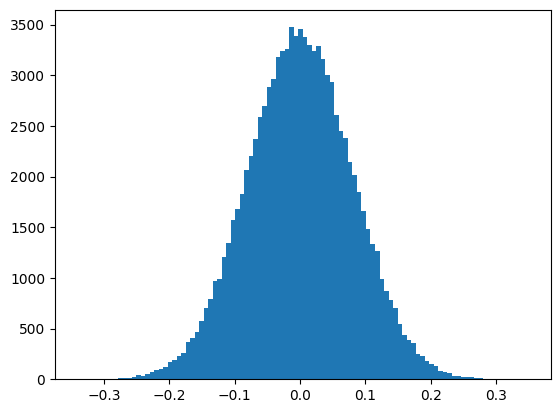

In [36]:
plt.hist(test_sample, bins=100)

In [47]:
np.floor(np.linspace(0, 5, 10)) % 2 > 0

array([False, False,  True,  True, False, False,  True,  True, False,
        True])

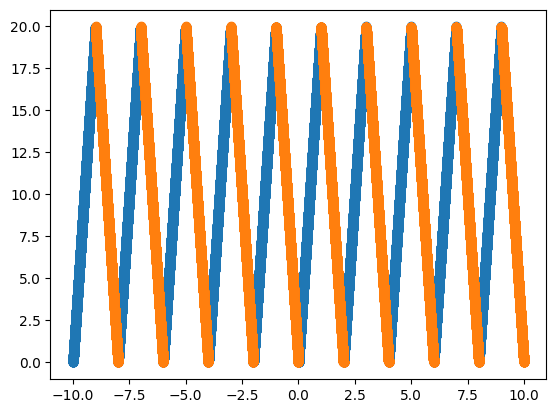

In [78]:
y = lambda x, offset, sign: sign*(20*x - offset)

x1_base = np.linspace(-10, 10, 100000)
x1 = x1_base[np.floor(x1_base) % 2 == 0]
x2_base = np.linspace(-10, 10, 100000)
x2 = x2_base[np.floor(x2_base) % 2 > 0]
Y = y(x1, np.floor(x1)*j, 1)
Y_2 = y(x2, (np.floor(x2)*j)+j, -1)

fig, ax = plt.subplots()
ax.scatter(x1, Y)
ax.scatter(x2, Y_2)

In [128]:
def periodic_triangular_function(x:float, j: int):
    y = lambda x, offset, sign: sign*(20*x - offset)
    if np.floor(x) % 2 == 0:
        # Even case -> positive slope
        cur_offset = np.floor(x)*j
        return np.round(y(x, cur_offset, 1))
    else:
        # Odd case -> negative slope
        cur_offset = (np.floor(x)*j)+j
        return np.round(y(x, cur_offset, -1))

def periodic_triangular_function_vectorized(x: np.ndarray, j: int) -> np.ndarray:
    y = lambda x, offset, sign: sign*(20*x - offset)
    y_res = np.empty_like(x)
    
    x1 = x[np.floor(x) % 2 == 0]
    x2 = x[np.floor(x) % 2 > 0]

    y_res[np.floor(x) % 2 == 0] = y(x1, np.floor(x1)*j, 1)
    y_res[np.floor(x) % 2 > 0] = y(x2, (np.floor(x2)*j)+j, -1)

    return np.round(y_res)


In [ ]:
test_list = []
cur_angle = 0.5

for i in range(10000):
    new_drawn_value = np.random.normal(0, 0.05) + cur_angle
    job_value = periodic_triangular_function(new_drawn_value, 20)
    test_list.append(job_value)

In [321]:
test_individual = np.random.uniform(size=m*j)
test_individual_2 = np.random.uniform(size=m*j)

test_random_keys = periodic_triangular_function_vectorized(np.random.normal(0, 0.01) + test_individual, j)
next_permutation = np.repeat(np.arange(j), m)[np.argsort(test_random_keys.astype(int))]

test_random_keys = periodic_triangular_function_vectorized(np.random.normal(0, 0.01) + test_individual_2, j)
next_permutation_2 = np.repeat(np.arange(j), m)[np.argsort(test_random_keys.astype(int))]

In [322]:
np.unique(next_permutation, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 array([20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 20, 20], dtype=int64))

In [323]:
def int_rotation(b: np.ndarray, x: np.ndarray):
    # transfer all angles into interval [0, 1]
    b_filtered = b - np.floor(b)
    x_filtered = x - np.floor(x)
    # Check if the two angles are within the variance
    equal_cases_overshoot = np.logical_and(np.abs(b_filtered - x_filtered) <= 0.01, (b_filtered - x_filtered) < 0)
    equal_cases_undershoot = np.logical_and(np.abs(b_filtered - x_filtered) <= 0.01, (b_filtered - x_filtered) > 0)
    unequal_cases_overshoot = np.logical_and(np.abs(b_filtered - x_filtered) > 0.01, (b_filtered - x_filtered) < 0)
    unequal_cases_undershoot = np.logical_and(np.abs(b_filtered - x_filtered) > 0.01, (b_filtered - x_filtered) > 0)
    
    x_filtered[equal_cases_overshoot] += 0 #np.random.uniform(0.01, 0.05)
    x_filtered[unequal_cases_overshoot] -= 0.01#np.random.uniform(0.01, 0.05)
    x_filtered[equal_cases_undershoot] -= 0 #np.random.uniform(0.01, 0.05)
    x_filtered[unequal_cases_undershoot] += 0.01#np.random.uniform(0.01, 0.05)
    x = x_filtered
    return x

In [324]:
next_permutation - next_permutation_2

array([  7, -10,  10,   1,   6,   0,  16,  -5, -11,   6,  -3,   6,   9,
         7,  -7,   8,   2,   5,  -8,  14,  10,  14,   6,   9, -12,  -4,
         5,   4,  -4,   1,  -6,   7,   7, -10, -10,  13,  17,  -2, -13,
         0,  -9, -10,   0,   3,  -1,  16,   3,  -5,   0, -16,  -2,   0,
         1,  -4,  11,   3,  -4,  -5,   9,   4, -16,   4,  12,   4,   3,
        12,   0,  11,   2,  14, -14,  -9,   0,   1,   3,  14,   9, -10,
        -3,   9,   1,  -6,  -8,  -7,  -5,   3,  -7,   1,  -9,  -6,   9,
        -3,  -7,   5, -11,   5,  16,  -7, -11, -13,  -6,  13,   4,  -8,
         2, -11,   0, -18,  -5,   3,  -5, -10,   5,  -4,   2,  -4,  -6,
        -2,  -2,  11,   3,   7,  -5,   4,  12,  -5,   9,  -3,   0,   8,
         4,   9,  12,   9, -14,  14, -16,  13, -10,   1,  15,  -4,   1,
       -16,  -7,   8,   6, -11,  -4,   1,  -4,   3,  -4,   5,  -6,  -8,
         3,  -4,   5, -11,  -5,   1,  13,  -1,  16,  14,   1,  -6,  -3,
        -3,  -2, -14,  -9,  -7,  -1,  -4,  -1,  -1, -10,   9,   

In [438]:
test_individual_2 = int_rotation(test_individual, test_individual_2)
test_random_keys = periodic_triangular_function_vectorized(np.random.normal(0, 0.01) + test_individual_2, j)
next_permutation_2 = np.repeat(np.arange(j), m)[np.argsort(test_random_keys.astype(int))]
print(np.abs(test_individual - test_individual_2)[np.abs(test_individual - test_individual_2) > 0.01])
print(np.all(np.abs(test_individual - test_individual_2) <= 0.01))
print(next_permutation - next_permutation_2)

[]
True
[ 11 -12   2   2   0   5   6 -15 -12  -7   2  12  10   9   1  -2   2  -3
  -8   4   5  12  -7  -7  -3  -4 -12   1 -11  -4 -13  -8   6  -6  -5  11
  -2   0  -9   7   8   9   5  -8   9  18 -12  -6   6  -9  -5   9  12 -15
  13   5   0   5  -1  11 -13  13   0   5  -1   1   2  -4  -6  14 -12   0
   7  10   1   7   7   2  -5   4  -3 -11 -12  -6  12  -7   3  -4  -6  -4
   5  -1   3  -4  -8   3   3 -12  -3   4  10  17  -4 -18  -2 -12  -5 -13
  -6   7   1 -14 -11   6   4   3   4   8   0   4   1   6  -6  12   3  -6
  -2  15  -2   3   5   6   0  -3  -4   7  -6   0 -12  -2   0   7  13   0
  -5  -2  14 -12 -12   5  -5   8   4   6   2  -3   4 -11   1 -11  -2   3
  10  -4   3   4   3  -5   7 -12   5  -7   3  -9   2   6 -15  -8  -8   9
   7  15  14  11   4   2   0  -6  -9   4   3  12 -17 -14 -14 -17   8 -12
 -12   2   4   2   0   1  -1   7  15   9   2  -4  -2  -3   2  -1  -5  -2
   1  -4   1  -1  -1   0   4   5 -11  16   2  11 -14   0  -3  -1  -1  -7
   2 -12  19  -9   4  15  -3   6  15  -4  1